# Telecom Customer Churn Prediction

Rework of the original Kaggle case study. See `docs/EXPLANATION.md` for the full methodology write-up and `original_work/` for the notebook this replaces.

## 1. Problem framing

Telecom operators lose 15-25% of customers annually, and acquiring a new customer costs 5-10x more than retaining one. This notebook predicts, from months 6-8 usage, which customers are at high risk of churning in month 9, and identifies the usage patterns that drive that risk.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay

from churn import config, data, preprocessing, features, pca as pca_mod, models, evaluate

np.random.seed(config.RANDOM_SEED)


## 2. Load & inspect data

In [2]:
train_raw = data.load_train()
test_raw = data.load_test()
data_dict = data.load_data_dictionary()

print("train:", train_raw.shape, "| test:", test_raw.shape)
train_raw[config.TARGET_COLUMN].value_counts(normalize=True).round(2)


train: (69999, 172) | test: (30000, 171)


churn_probability
0    0.9
1    0.1
Name: proportion, dtype: float64

## 3. Cleaning

Drop columns >60% missing, constant columns, date columns, and `id` -- computed on train, then applied identically to test so both stay on the same schema. Remaining nulls (all under 7%) are median-imputed with a single imputer fit on train only. (Here, and through section 5, "train"/"test" mean the labeled `train.csv` and unseen `test.csv` Kaggle files; section 6 introduces a separate internal 70/30 split of the labeled data and reuses "train"/"test" for that split instead.)

In [3]:
test_ids = test_raw[config.ID_COLUMN].copy()

drop_cols = data.compute_drop_columns(train_raw)
train_clean = data.apply_column_drops(train_raw, drop_cols)
test_clean = data.apply_column_drops(test_raw, drop_cols)

null_cols = train_clean.columns[train_clean.isnull().any()].tolist()
imputer = preprocessing.fit_median_imputer(train_clean, null_cols)
train_clean = preprocessing.apply_imputer(train_clean, null_cols, imputer)
test_clean = preprocessing.apply_imputer(test_clean, null_cols, imputer)

print("dropped", len(drop_cols), "columns; imputed", len(null_cols), "columns")
train_clean.shape, test_clean.shape


dropped 47 columns; imputed 81 columns


((69999, 125), (30000, 124))

## 4. Feature engineering

`avg_customer_Spend` combines age-on-network with average revenue; `customer_value` buckets customers into HVC/MVC/LVC by that spend. The HVC/LVC quantile thresholds are computed on train and reused for test -- an unseen customer's bucket depends only on what was learned from training data.

In [4]:
train_fe, value_thresholds = features.engineer_customer_value(train_clean)
test_fe, _ = features.engineer_customer_value(test_clean, thresholds=value_thresholds)

train_fe["customer_value"].value_counts()


customer_value
1    31499
2    24500
0    14000
Name: count, dtype: int64

## 5. Exploratory data analysis

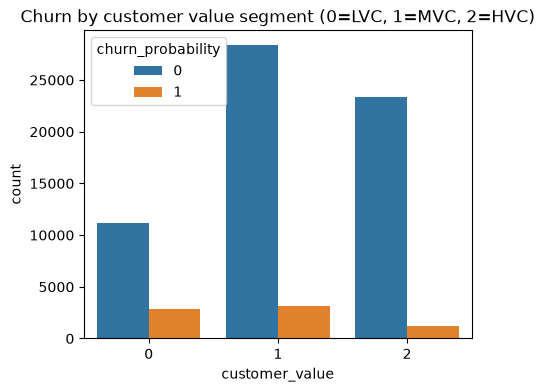

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="customer_value", hue=config.TARGET_COLUMN, data=train_fe, ax=ax)
ax.set_title("Churn by customer value segment (0=LVC, 1=MVC, 2=HVC)")
fig.savefig(config.FIGURES_DIR / "churn_by_customer_value.png", bbox_inches="tight")
plt.show()


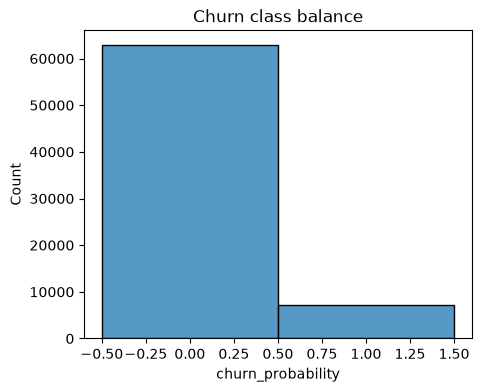

churn_probability
0    0.898
1    0.102
Name: proportion, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.histplot(train_fe[config.TARGET_COLUMN], ax=ax, discrete=True)
ax.set_title("Churn class balance")
fig.savefig(config.FIGURES_DIR / "churn_class_balance.png", bbox_inches="tight")
plt.show()

train_fe[config.TARGET_COLUMN].value_counts(normalize=True).round(3)


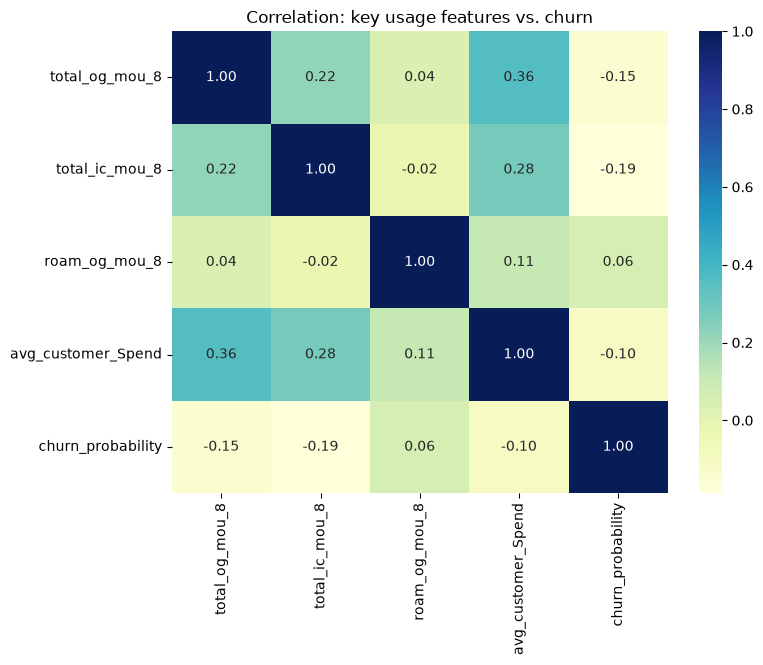

In [7]:
key_cols = ["total_og_mou_8", "total_ic_mou_8", "roam_og_mou_8", "avg_customer_Spend", config.TARGET_COLUMN]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(train_fe[key_cols].corr(), annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Correlation: key usage features vs. churn")
fig.savefig(config.FIGURES_DIR / "correlation_key_features.png", bbox_inches="tight")
plt.show()


## 6. Outlier treatment (labeled data only) and the internal train/test split

Outliers are removed only from the minutes-of-use and recharge-amount columns, only where a column's max exceeds 6x its 99th percentile, and only from the full labeled train.csv -- the unseen Kaggle set is never row-filtered, so every one of its 30,000 rows still gets a prediction. From here through section 10, "train"/"test" refer to the internal 70/30 split created below, not the Kaggle train.csv/test.csv files from sections 2-5.

In [8]:
train_trimmed = preprocessing.remove_outliers(train_fe)
print(f"train rows: {len(train_fe)} -> {len(train_trimmed)} "
      f"({100 * (len(train_fe) - len(train_trimmed)) / len(train_fe):.1f}% removed)")

X = train_trimmed.drop(columns=[config.TARGET_COLUMN])
y = train_trimmed[config.TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=config.TRAIN_SIZE, random_state=config.RANDOM_SEED, stratify=y
)
X_train.shape, X_test.shape


train rows: 69999 -> 67239 (3.9% removed)


((47067, 122), (20172, 122))

## 7. Scaling + PCA

Both are fit on `X_train` only. `X_test` and the unseen set are transformed with those same fitted objects -- never refit.

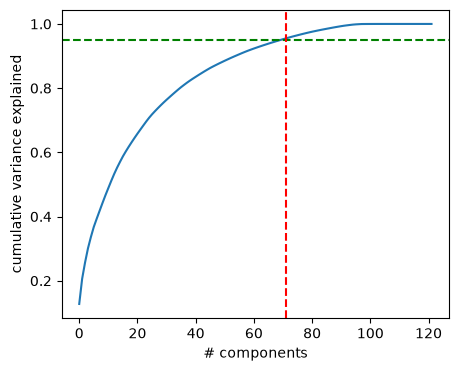

71 components explain 95% of variance


In [9]:
scaler = preprocessing.fit_scaler(X_train)
X_train_scaled = preprocessing.apply_scaler(X_train, scaler)
X_test_scaled = preprocessing.apply_scaler(X_test, scaler)

var_curve = pca_mod.explained_variance_curve(X_train_scaled)
n_for_95 = int(np.searchsorted(var_curve, 0.95) + 1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(var_curve)
ax.axhline(0.95, color="g", linestyle="--")
ax.axvline(n_for_95, color="r", linestyle="--")
ax.set_xlabel("# components")
ax.set_ylabel("cumulative variance explained")
fig.savefig(config.FIGURES_DIR / "pca_scree.png", bbox_inches="tight")
plt.show()
print(f"{n_for_95} components explain 95% of variance")


In [10]:
pca_model = pca_mod.fit_pca(X_train_scaled, n_components=config.N_PCA_COMPONENTS)
X_train_pca = pca_mod.transform_pca(X_train_scaled, pca_model)
X_test_pca = pca_mod.transform_pca(X_test_scaled, pca_model)
X_train_pca.shape


(47067, 70)

## 8. Models

Logistic regression trains on the PCA components (a linear model benefits from decorrelated inputs). Random Forest and XGBoost train on the original scaled features directly -- tree ensembles handle multicollinearity fine, and skipping PCA keeps feature-level importance meaningful for the recommendations in section 13.

In [11]:
lr_search = models.train_logistic_regression(X_train_pca, y_train)
print("Logistic Regression best CV ROC-AUC:", round(lr_search.best_score_, 3), lr_search.best_params_)


Logistic Regression best CV ROC-AUC: 0.877 {'C': 5, 'class_weight': {0: 0.2, 1: 0.8}}


### Statistical significance of the PCA components

The original notebook's README claimed statsmodels was used to check coefficient significance, but the actual notebook never imported or called it. This fits that claim for real: `sm.Logit` on the same PCA-transformed train data gives a p-value per component, so we know which ones are statistically meaningful rather than just eyeballing `LogisticRegression`'s coefficients.

In [12]:
import statsmodels.api as sm

X_train_pca_sm = sm.add_constant(pd.DataFrame(X_train_pca, index=y_train.index))
logit_model = sm.Logit(y_train, X_train_pca_sm).fit(disp=False)
significant = logit_model.pvalues[logit_model.pvalues < 0.05]
print(f"{len(significant)} of {len(logit_model.pvalues)} terms (70 PCA components + intercept) are significant at p<0.05")
logit_model.summary2().tables[1].sort_values("P>|z|").head(10)


C:\Users\mboyini\Documents\MB_Docs\ML_Projects\Telecom_Churn_Case_Study-main\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:2620: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-X))


58 of 71 terms (70 PCA components + intercept) are significant at p<0.05


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-3.840831,0.046310,-82.938263,0.000000e+00,-3.931596,-3.750066
7,0.740753,0.019382,38.218379,0.000000e+00,0.702764,0.778741
0,-0.412361,0.011534,-35.751192,6.339462e-280,-0.434967,-0.389754
21,0.537479,0.024851,21.628086,9.775488e-104,0.488772,0.586186
28,0.529721,0.026207,20.212756,7.560594e-91,0.478356,0.581087
1,0.213389,0.012692,16.813254,1.951590e-63,0.188514,0.238264
29,0.412462,0.031000,13.305280,2.156830e-40,0.351703,0.473221
23,-0.717151,0.056755,-12.635976,1.337245e-36,-0.828388,-0.605914
4,-0.255515,0.021399,-11.940709,7.260178e-33,-0.297456,-0.213575
22,-0.686450,0.058055,-11.824228,2.925810e-32,-0.800235,-0.572665


In [13]:
rf_search = models.train_random_forest(X_train_scaled, y_train)
print("Random Forest best CV ROC-AUC:", round(rf_search.best_score_, 3), rf_search.best_params_)


Random Forest best CV ROC-AUC: 0.937 {'min_samples_leaf': 30, 'n_estimators': 200}


In [14]:
xgb_search = models.train_xgboost(X_train_scaled, y_train)
print("XGBoost best CV ROC-AUC:", round(xgb_search.best_score_, 3), xgb_search.best_params_)


XGBoost best CV ROC-AUC: 0.941 {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


## 9. Comparison

In [15]:
fitted = {
    "Logistic Regression": (lr_search.best_estimator_, X_test_pca),
    "Random Forest": (rf_search.best_estimator_, X_test_scaled),
    "XGBoost": (xgb_search.best_estimator_, X_test_scaled),
}

results = {}
for name, (model, X_eval) in fitted.items():
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba > 0.5).astype(int)
    results[name] = evaluate.compute_metrics(y_test, pred, proba)

comparison = evaluate.comparison_table(results)
comparison


,accuracy,precision,recall,f1,roc_auc,pr_auc
Logistic Regression,0.878644,0.440723,0.726074,0.548506,0.879278,0.460689
Random Forest,0.934910,0.664872,0.723633,0.693009,0.941751,0.754841
XGBoost,0.910420,0.537857,0.835938,0.654559,0.943727,0.759338


In [16]:
# Train ROC-AUC, for comparison against the Test ROC-AUC above -- this,
# not the CV score, is the real overfitting signal. CV-best and test are
# both held-out estimates, so agreeing with each other says the CV
# procedure is reliable, not that a model isn't overfitting relative to
# what it saw during training.
train_eval = {
    "Logistic Regression": X_train_pca,
    "Random Forest": X_train_scaled,
    "XGBoost": X_train_scaled,
}
print("Train ROC-AUC:")
for name, (model, _) in fitted.items():
    train_proba = model.predict_proba(train_eval[name])[:, 1]
    train_pred = (train_proba > 0.5).astype(int)
    train_auc = evaluate.compute_metrics(y_train, train_pred, train_proba)["roc_auc"]
    print(f"  {name}: {train_auc:.4f}")


Train ROC-AUC:
  Logistic Regression: 0.8800


  Random Forest: 0.9747
  XGBoost: 0.9721


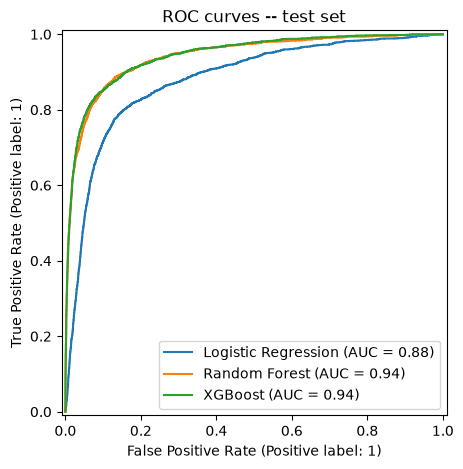

In [17]:
comparison.to_csv(config.FIGURES_DIR / "model_comparison.csv")

fig, ax = plt.subplots(figsize=(6, 5))
for name, (model, X_eval) in fitted.items():
    RocCurveDisplay.from_estimator(model, X_eval, y_test, ax=ax, name=name)
ax.set_title("ROC curves -- test set")
fig.savefig(config.FIGURES_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()


## 10. Threshold tuning

Each model's submission threshold is chosen by maximizing F1 on the test split -- unlike the original notebook's logistic-regression path, which explored cutoffs of 0.33/0.6 but then submitted with an unexamined default of 0.5 instead, here that exact F1-optimal threshold is what gets used for the submission in section 12. F1 weights precision and recall equally, though, so it doesn't specifically favor catching more churners the way a "a missed churner costs more than a false alarm" argument would call for -- see docs/EXPLANATION.md for why that matters here.

In [18]:
submission_thresholds = {}
for name, (model, X_eval) in fitted.items():
    proba = model.predict_proba(X_eval)[:, 1]
    threshold, _ = evaluate.select_threshold(y_test, proba)
    submission_thresholds[name] = threshold

best_name = comparison["roc_auc"].idxmax()
print("Best model by test ROC-AUC:", best_name)
submission_thresholds


Best model by test ROC-AUC: XGBoost


{'Logistic Regression': np.float64(0.55),
 'Random Forest': np.float64(0.6),
 'XGBoost': np.float64(0.8)}

In [19]:
# `comparison` above uses a uniform 0.5 cutoff for accuracy/precision/
# recall/F1 so the three models are compared on equal footing (ROC-AUC/
# PR-AUC are threshold-independent either way). Each model's actual
# submission uses its OWN tuned threshold instead -- this table shows
# what each model's metrics look like at the threshold it's actually
# submitted with, so that number is the one to cite as "how the
# submitted model performs," not the 0.5-cutoff row above.
threshold_metrics = {}
for name, (model, X_eval) in fitted.items():
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba > submission_thresholds[name]).astype(int)
    threshold_metrics[name] = evaluate.compute_metrics(y_test, pred, proba)
    threshold_metrics[name]["threshold"] = submission_thresholds[name]

threshold_metrics_df = pd.DataFrame(threshold_metrics).T
threshold_metrics_df.to_csv(config.FIGURES_DIR / "model_comparison_at_submission_threshold.csv")
threshold_metrics_df


,accuracy,precision,recall,f1,roc_auc,pr_auc,threshold
Logistic Regression,0.892177,0.477882,0.669922,0.557837,0.879278,0.460689,0.55
Random Forest,0.940660,0.720810,0.678223,0.698868,0.941751,0.754841,0.60
XGBoost,0.942842,0.726812,0.700195,0.713255,0.943727,0.759338,0.80


## 11. Feature importance

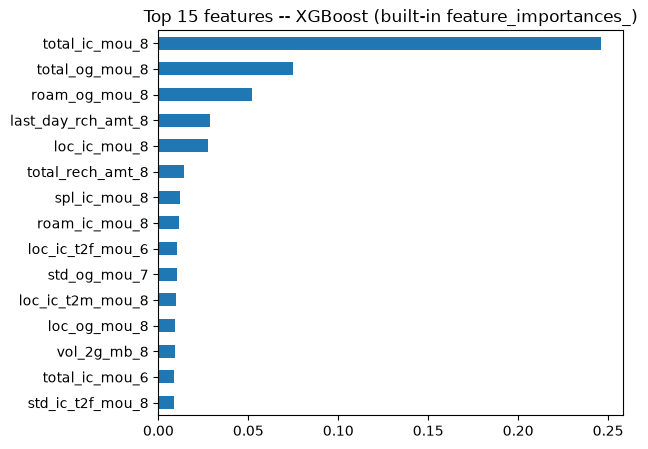

D:\tmp\ipykernel_38016\1641379943.py:25: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, shap_sample, show=False)


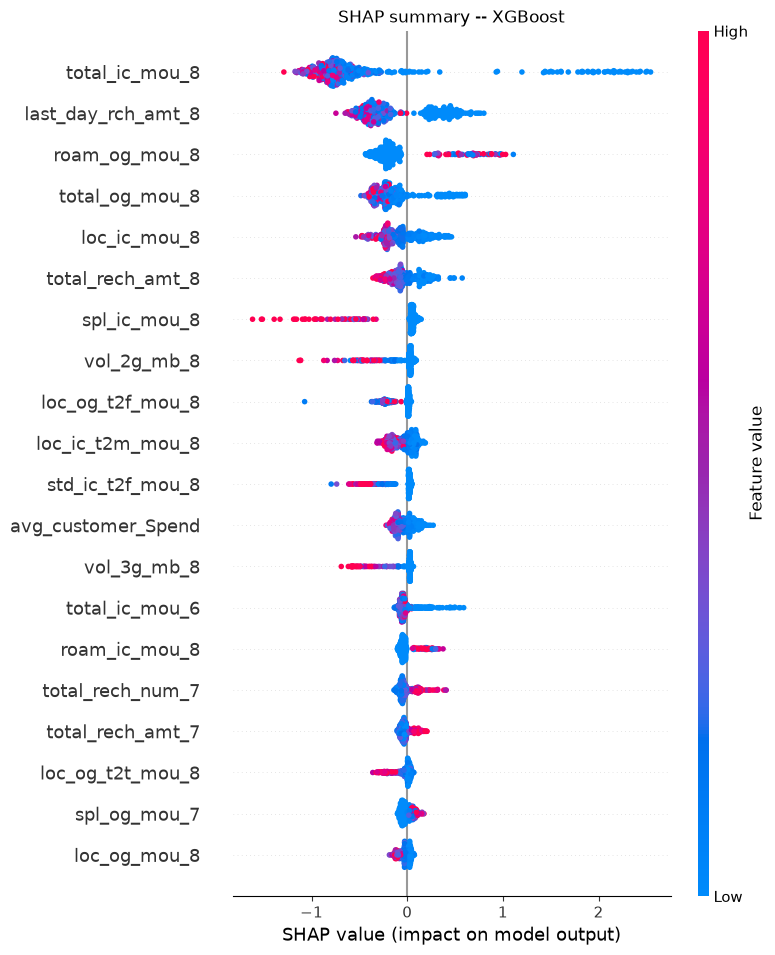

total_ic_mou_8        0.246189
total_og_mou_8        0.074629
roam_og_mou_8         0.051960
last_day_rch_amt_8    0.028881
loc_ic_mou_8          0.027484
total_rech_amt_8      0.014070
spl_ic_mou_8          0.011990
roam_ic_mou_8         0.011520
loc_ic_t2f_mou_6      0.010610
std_og_mou_7          0.010191
loc_ic_t2m_mou_8      0.009646
loc_og_mou_8          0.009172
vol_2g_mb_8           0.009115
total_ic_mou_6        0.008870
std_ic_t2f_mou_8      0.008565
dtype: float32

In [20]:
best_model, best_X_eval = fitted[best_name]

if best_name != "Logistic Regression":
    importance = pd.Series(
        best_model.feature_importances_, index=X_train_scaled.columns
    ).sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(6, 5))
    importance.plot.barh(ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Top 15 features -- {best_name} (built-in feature_importances_)")
    fig.savefig(config.FIGURES_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()

    try:
        import shap

        shap_sample = X_train_scaled.sample(n=min(500, len(X_train_scaled)), random_state=config.RANDOM_SEED)
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(shap_sample)
        if isinstance(shap_values, list):  # older shap API: one array per class
            shap_values = shap_values[1]

        plt.figure(figsize=(6, 5))
        shap.summary_plot(shap_values, shap_sample, show=False)
        plt.title(f"SHAP summary -- {best_name}")
        plt.savefig(config.FIGURES_DIR / "shap_summary.png", bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print(f"SHAP summary skipped ({exc}); feature_importances_ above still holds.")
else:
    importance = None
    print("Best model is Logistic Regression -- see the statsmodels p-values above instead of tree feature_importances_/SHAP.")

importance


## 12. Predict on the unseen (Kaggle) set

The unseen set gets the exact same drop list, the same fitted imputer, the same fitted scaler, the same fitted PCA, and the same value-bucket thresholds as train -- nothing is refit on it. All 30,000 rows get a prediction; none are dropped, since outlier removal in section 6 only ever touched the labeled train.csv data.

In [21]:
X_unseen_scaled = preprocessing.apply_scaler(test_fe, scaler)
X_unseen_pca = pca_mod.transform_pca(X_unseen_scaled, pca_model)

for name, (model, _) in fitted.items():
    X_unseen_eval = X_unseen_pca if name == "Logistic Regression" else X_unseen_scaled
    proba_unseen = model.predict_proba(X_unseen_eval)[:, 1]
    pred_unseen = (proba_unseen > submission_thresholds[name]).astype(int)

    submission = pd.DataFrame({"id": test_ids, config.TARGET_COLUMN: pred_unseen})
    assert len(submission) == len(test_raw), f"{name}: expected {len(test_raw)} rows, got {len(submission)}"
    assert set(submission["id"]) == set(test_ids), f"{name}: id mismatch against test.csv"

    slug = name.lower().replace(" ", "_")
    submission.to_csv(config.SUBMISSIONS_DIR / f"submission_{slug}.csv", index=False)

print("Wrote", len(fitted), "submission files to outputs/submissions/")


Wrote 3 submission files to outputs/submissions/


## 13. Business recommendations

1. The dominant churn signal in this data is a month-8 drop in usage and recharge activity, not roaming or STD: total incoming minutes in month 8 (total_ic_mou_8) has the strongest correlation with churn in section 5's heatmap, and it's also the single most important feature for the winning model in section 11 -- roughly 3x the importance of the next usage-pattern feature. Roaming and STD usage are real but secondary signals (much weaker correlation, lower importance); reassessing them is still worth doing, but retention effort should lead with re-engaging customers whose month-8 usage and recharge activity is dropping.
2. Voice usage matters more than data usage for retention here; with no direct evidence here either way on network quality, the opportunity is on the data side -- more competitive data packages could convert an already-loyal voice customer into a fully loyal one.
3. Segment-level churn (section 5) is stark: low-value customers churn at roughly double the rate of medium-value customers, and high-value customers churn least of all -- retention spend aimed at keeping medium-value customers from sliding into low-value usage patterns is likely higher-leverage than a blanket offer.
4. This model flags who is at risk, not why they're unhappy -- pair it with direct customer feedback (support tickets, surveys) to validate these drivers before committing large-scale retention spend.
5. Limitation: Random Forest and XGBoost both show a real train/test overfitting gap here too, comparable in size to the original notebook -- train ROC-AUC (printed in section 9) is roughly 0.97 for both, about 0.03 above their test ROC-AUC (~0.94). Their cross-validated score during tuning (section 8) tracks test ROC-AUC closely (within ~0.005), which is a separate, reassuring signal that the CV procedure itself estimates held-out performance reliably -- it isn't evidence against overfitting, since CV and test are both held-out measurements, neither is a training-set one. The more actionable caveat is that each model's submission threshold (section 10) is chosen by maximizing F1 on the same test split the comparison table already reports on -- both numbers come from the same held-out data, so treat them as mildly optimistic and re-validate on a genuinely separate month before using this to drive spend decisions.